# Difference plot for understanding the variation in the star formation rate as a function of radial profile
### The binning in the radial profile can be adjusted as per the preference 
### The code also gives the points that are greater than 0 and gives a summary of all the points that are NaN and are 0.

=== Data Quality Summary ===
Paα (JWST):
  Total points        = 9015
  Valid (>0, finite)  = 8816
  NaN or ≤0 (invalid) = 199

Leroy+13:
  Total points        = 9015
  Valid (>0, finite)  = 8424
  NaN or ≤0 (invalid) = 591



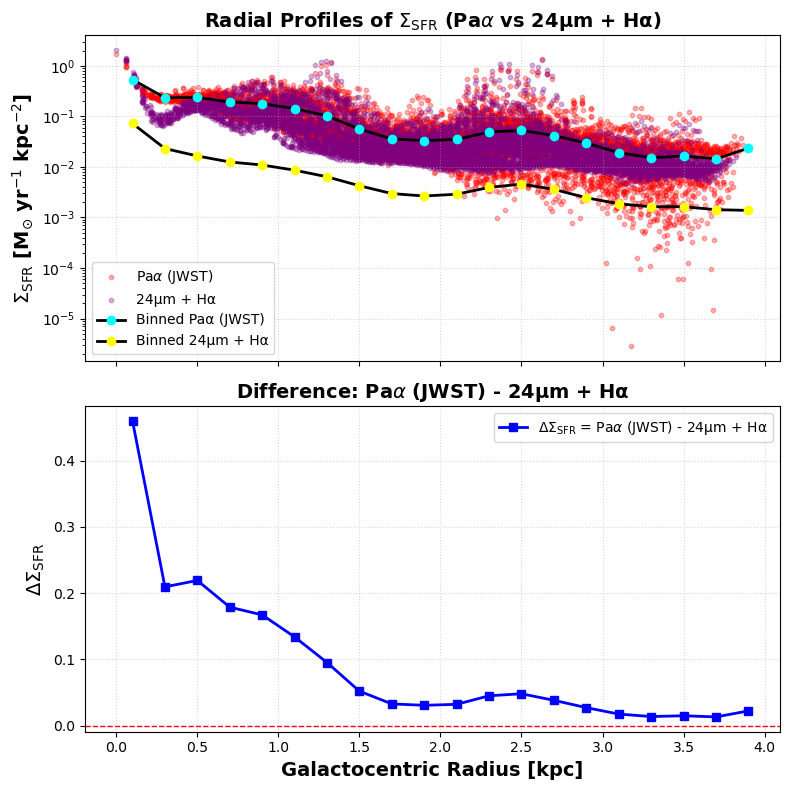

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Example arrays you already have:
# rgal_kpc        → Galactocentric radius [kpc]
# sig_SFR_kpc2    → Σ_SFR (Paα, JWST)
# sigma_SFR       → Σ_SFR (Leroy et al. 2013)

# ---------------------------------------
# Define radial bins
# ---------------------------------------
bin_width = 0.2  # kpc
bins = np.arange(0, np.max(rgal_kpc) + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# ---------------------------------------
# Clean data: remove NaNs and non-positive values (for log-scale safety)
# ---------------------------------------
valid_pa = (sig_SFR_kpc2 > 0) & np.isfinite(sig_SFR_kpc2)
valid_sigma = (uc_sfr > 0) & np.isfinite(uc_sfr)

# --- Print summary of data quality ---
print("=== Data Quality Summary ===")
print(f"Paα (JWST):")
print(f"  Total points        = {len(sig_SFR_kpc2)}")
print(f"  Valid (>0, finite)  = {np.sum(valid_pa)}")
print(f"  NaN or ≤0 (invalid) = {len(sig_SFR_kpc2) - np.sum(valid_pa)}\n")

print(f"Leroy+13:")
print(f"  Total points        = {len(uc_sfr)}")
print(f"  Valid (>0, finite)  = {np.sum(valid_sigma)}")
print(f"  NaN or ≤0 (invalid) = {len(uc_sfr) - np.sum(valid_sigma)}")
print("============================\n")

# ---------------------------------------
# Bin the data and compute mean values
# ---------------------------------------
mean_pa_sfr = []
mean_sigma_SFR = []

for i in range(len(bins) - 1):
    mask_pa = valid_pa & (rgal_kpc >= bins[i]) & (rgal_kpc < bins[i + 1])
    mask_sigma = valid_sigma & (rgal_kpc >= bins[i]) & (rgal_kpc < bins[i + 1])
    
    mean_pa_sfr.append(np.nanmean(sig_SFR_kpc2[mask_pa]))
    mean_sigma_SFR.append(np.nanmean(sigma_SFR[mask_sigma]))

mean_pa_sfr = np.array(mean_pa_sfr)
mean_sigma_SFR = np.array(mean_sigma_SFR)

# Compute difference: Leroy+13 - JWST Paα
diff_sfr = mean_pa_sfr - mean_sigma_SFR

# ---------------------------------------
# Make the plot (two panels)
# ---------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# --- Top panel: Σ_SFR profiles ---
ax = axes[0]

# Scatter points
ax.scatter(rgal_kpc[valid_pa], sig_SFR_kpc2[valid_pa], s=10, c='red', alpha=0.3, label=r'Pa$\alpha$ (JWST)')
ax.scatter(rgal_kpc[valid_sigma], uc_sfr[valid_sigma], s=10, c='purple', alpha=0.3, label=r'24μm + Hα')
ax.grid(True, ls=":", alpha=0.5)

# Binned profiles
ax.plot(bin_centers, mean_pa_sfr, 'o-', lw=2, color='black',
        markerfacecolor='cyan', markeredgecolor='cyan', label='Binned Paα (JWST)')
ax.plot(bin_centers, mean_sigma_SFR, 'o-', lw=2, color='black',
        markerfacecolor='yellow', markeredgecolor='yellow', label='Binned 24μm + Hα')


# Axis settings
ax.set_yscale('log')
ax.set_ylabel(r'$\Sigma_{\mathrm{SFR}}$ [M$_{\odot}$ yr$^{-1}$ kpc$^{-2}$]', fontweight='bold', fontsize=14)
ax.legend()
ax.set_title(r'Radial Profiles of $\Sigma_{\mathrm{SFR}}$ (Pa$\alpha$ vs 24μm + Hα)', fontweight='bold', fontsize=14)
plt.grid(True, ls=":", alpha=0.5)

# --- Bottom panel: Difference profile ---
ax = axes[1]
ax.plot(bin_centers, diff_sfr, 's-', c='blue', lw=2,
        label=r'$\Delta\Sigma_{\mathrm{SFR}}$ = Pa$\alpha$ (JWST) - 24μm + Hα')
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_xlabel('Galactocentric Radius [kpc]', fontweight='bold', fontsize=14)
ax.set_ylabel(r'$\Delta\Sigma_{\mathrm{SFR}}$', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
plt.grid(True, ls=":", alpha=0.5)
ax.set_title(r'Difference: Pa$\alpha$ (JWST) - 24μm + Hα', fontweight='bold', fontsize=14)

# ---------------------------------------
# Final layout and save
# ---------------------------------------
plt.tight_layout()
plt.grid(True, ls=":", alpha=0.5)
plt.show()


### Implementation of this code to all the tracers 

/var/folders/m3/yz4ltmh13wz1fqwj_nx6m9pc0000gn/T/ipykernel_79427/3159588622.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


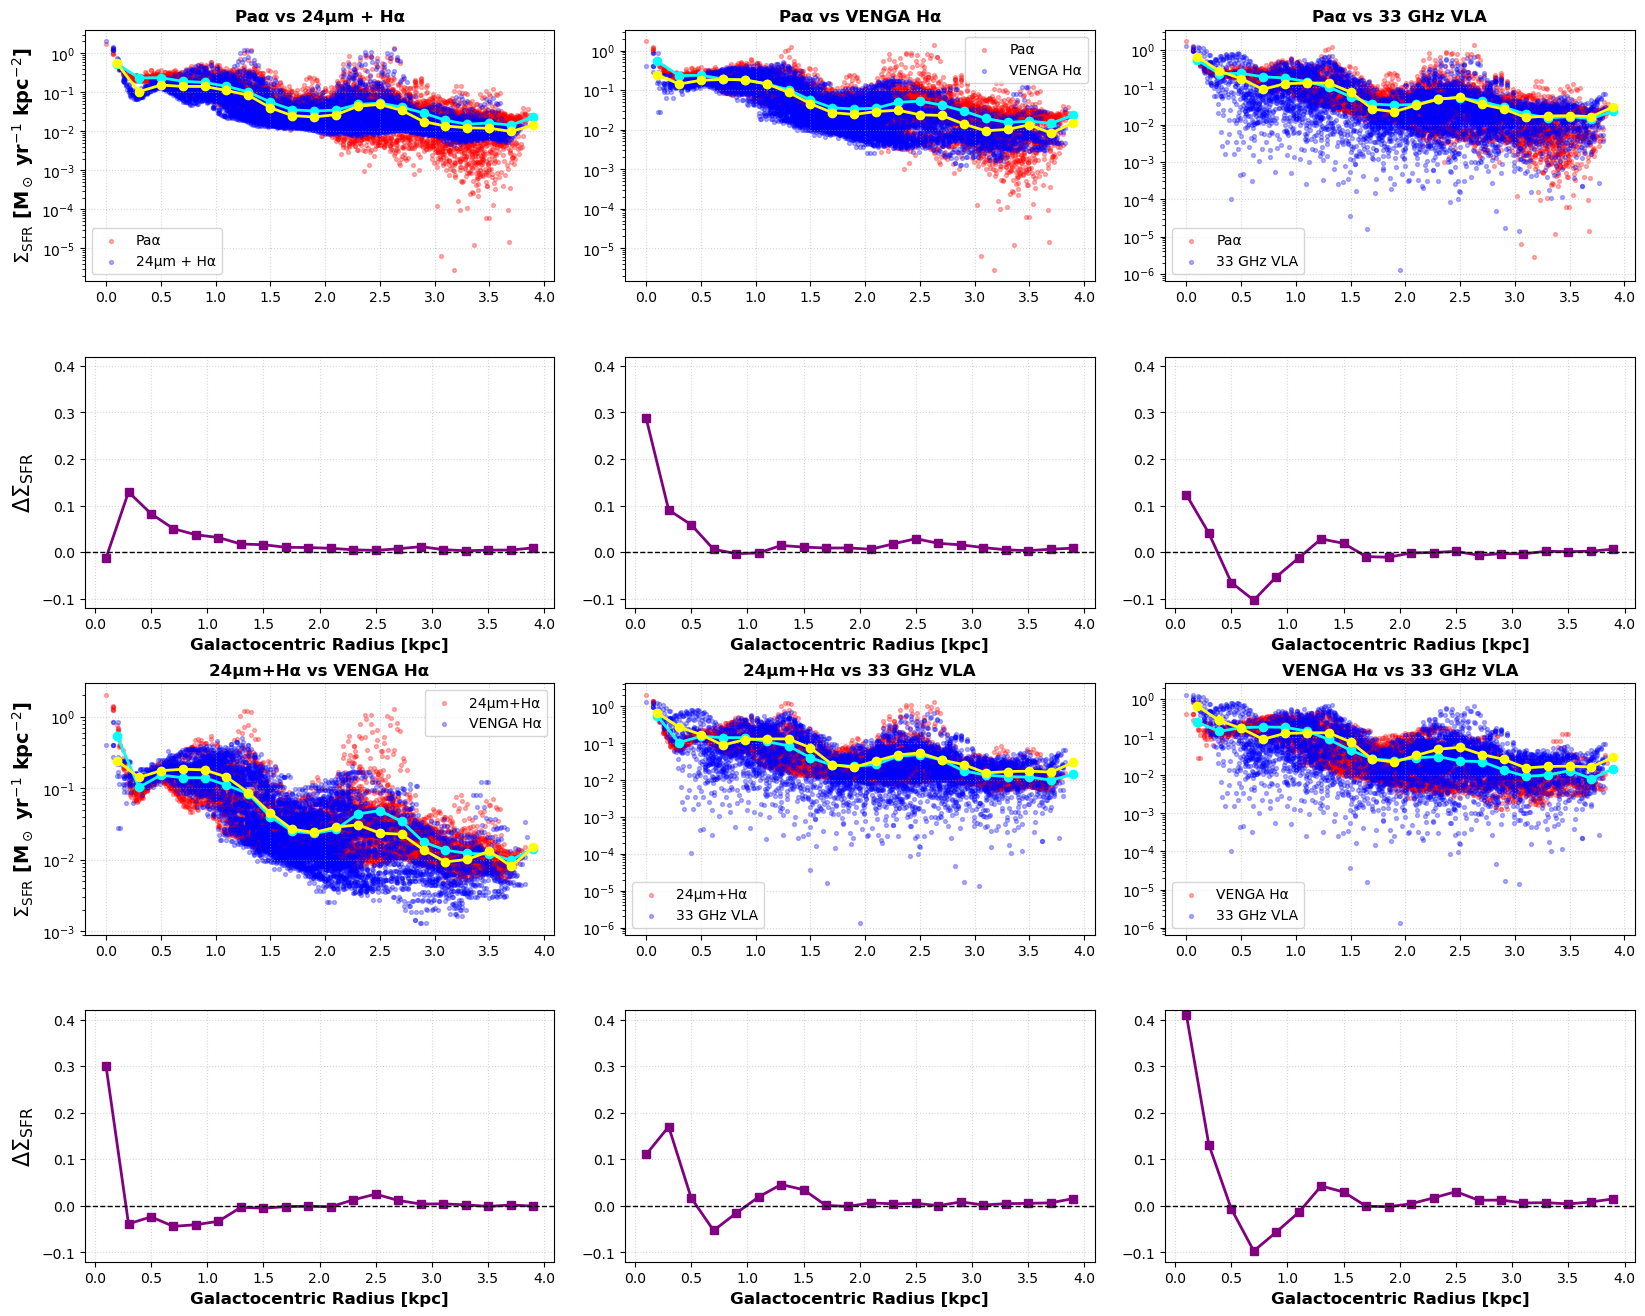

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ------------------------------------------------------
# Tracer pairs (with labels)
# ------------------------------------------------------
pairs = [
    ("Paα", sig_SFR_kpc2, "24µm + Hα", uc_sfr),
    ("Paα", sig_SFR_kpc2, "VENGA Hα", sigma_sfr_venga_extinction_corr),
    ("Paα", sig_SFR_kpc2, "33 GHz VLA", sigma_sfr_vla),

    ("24µm+Hα", uc_sfr, "VENGA Hα", sigma_sfr_venga_extinction_corr),
    ("24µm+Hα", uc_sfr, "33 GHz VLA", sigma_sfr_vla),
    ("VENGA Hα", sigma_sfr_venga_extinction_corr, "33 GHz VLA", sigma_sfr_vla),
]

# ------------------------------------------------------
# Difference swap indices
# ------------------------------------------------------
swap_indices = [2, 4, 5]

# ------------------------------------------------------
# Radial bins
# ------------------------------------------------------
bin_width = 0.2
bins = np.arange(0, np.max(rgal_kpc) + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# ------------------------------------------------------
# NEW GRID: 4 rows × 3 columns
# Added extra vertical spacing with hspace=0.75
# ------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(
    4, 3,
    height_ratios=[2, 2, 2, 2],
    wspace=0.15,
    hspace=0.30   # <<< EXTRA GAP BETWEEN UPPER AND LOWER PANELS
)

# ------------------------------------------------------
# Plotting loop
# ------------------------------------------------------
for i, (label1, sfr1, label2, sfr2) in enumerate(pairs):

    valid1 = (sfr1 > 0) & np.isfinite(sfr1)
    valid2 = (sfr2 > 0) & np.isfinite(sfr2)

    # binned profiles
    mean1, mean2 = [], []
    for b in range(len(bins)-1):
        mask1 = valid1 & (rgal_kpc >= bins[b]) & (rgal_kpc < bins[b+1])
        mask2 = valid2 & (rgal_kpc >= bins[b]) & (rgal_kpc < bins[b+1])
        mean1.append(np.nanmean(sfr1[mask1]))
        mean2.append(np.nanmean(sfr2[mask2]))

    mean1 = np.array(mean1)
    mean2 = np.array(mean2)

    # difference (with swapping)
    if i in swap_indices:
        diff = mean2 - mean1
    else:
        diff = mean1 - mean2

    # Determine grid coordinates
    col = i % 3
    if i < 3:
        row_top = 0
        row_diff = 1
    else:
        row_top = 2
        row_diff = 3

    # =====================================================
    # TOP PANEL
    # =====================================================
    ax_top = fig.add_subplot(gs[row_top, col])

    ax_top.scatter(rgal_kpc[valid1], sfr1[valid1], s=8, c='red', alpha=0.3, label=label1)
    ax_top.scatter(rgal_kpc[valid2], sfr2[valid2], s=8, c='blue', alpha=0.3, label=label2)

    ax_top.plot(bin_centers, mean1, 'o-', lw=2, color='cyan')
    ax_top.plot(bin_centers, mean2, "o-", color='yellow', lw=2)

    ax_top.set_yscale("log")
    ax_top.set_title(f"{label1} vs {label2}", fontsize=12, fontweight='bold')
    ax_top.grid(True, ls=":", alpha=0.5)

    if col == 0 and row_top == 0:
        ax_top.set_ylabel(r"$\Sigma_{\mathrm{SFR}}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]", fontsize=14, fontweight='bold')
    elif col == 0 and row_top == 2:
        ax_top.set_ylabel(r"$\Sigma_{\mathrm{SFR}}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]", fontsize=14, fontweight='bold')
    else:
        ax_top.set_ylabel("", fontsize=14, fontweight='bold')

    ax_top.legend(fontsize=10)

    # =====================================================
    # BOTTOM PANEL
    # =====================================================
    ax_bot = fig.add_subplot(gs[row_diff, col])

    ax_bot.plot(bin_centers, diff, "s-", c='purple', lw=2)
    ax_bot.axhline(0, color="black", ls="--", lw=1)
    ax_bot.grid(True, ls=":", alpha=0.5)
    ax_bot.set_ylim(-0.12, 0.42)

    ax_bot.set_xlabel("Galactocentric Radius [kpc]", fontsize=12, fontweight='bold')

    if col == 0:
        ax_bot.set_ylabel(r"$\Delta\Sigma_{\mathrm{SFR}}$", fontsize=16, fontweight='bold')
    else:
        ax_bot.set_ylabel("")

plt.tight_layout()
plt.show()


## In the following code the points with high value of SFR and $\Sigma_{SFR}$ and then plot them onto the map of the galaxy. 
### The detail regarding the method used for finding the high value of SFR and $\Sigma_{SFR}$ is given breifly in the code if required you can drop a message and I can share the detailed explanation.

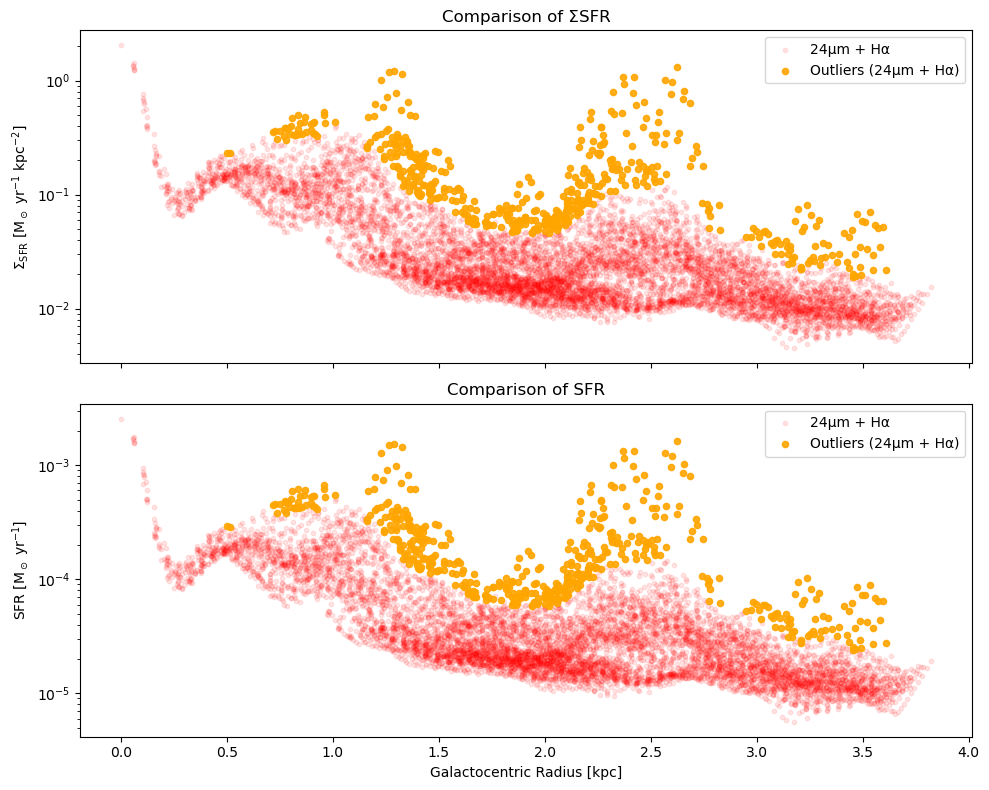

508
414


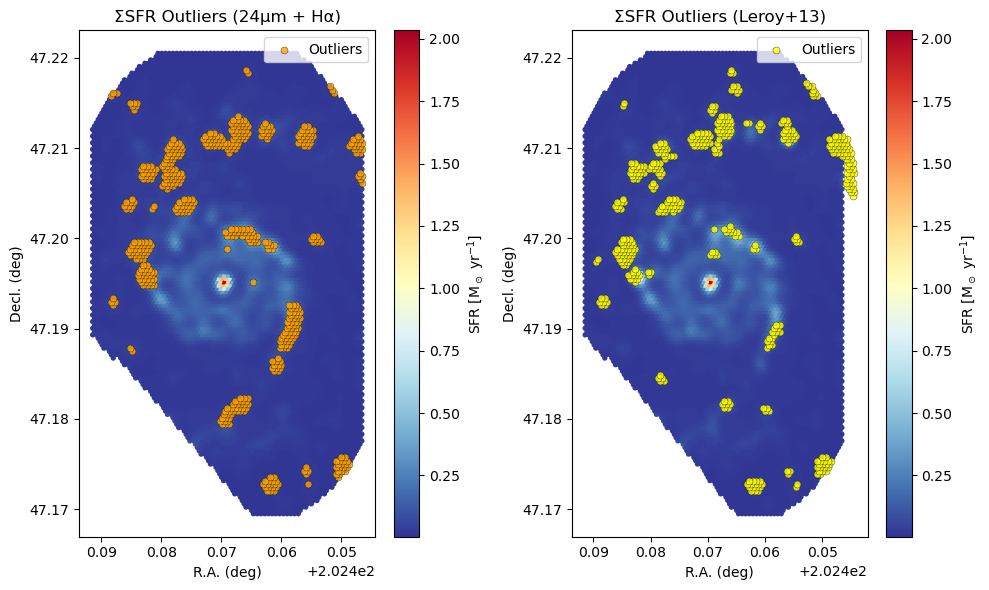

In [29]:
import numpy as np
import matplotlib.pyplot as plt
# Basic arrays
rgal_kpc = struct["rgal_kpc"]
ra = struct["ra_deg"]
dec = struct["dec_deg"]
int_sfr = struct["INT_VAL_SIGMA_SFR24UM+HA"]

# --- Helper function: 1D radial profile MAD ---
def identify_outliers_radial(y, r, window_kpc=0.05, threshold=4.5):
    y = np.array(y)
    r = np.array(r)
    mask = ~np.isnan(y) & (y != 0)
    outliers = np.zeros_like(y, dtype=bool)
    
    for i in range(len(y)):
        if not mask[i]:
            continue
        # Select neighbors within the window
        neighbors = (r >= r[i] - window_kpc/2) & (r <= r[i] + window_kpc/2) & mask
        if np.sum(neighbors) < 3:
            continue
        local_values = y[neighbors]
        median = np.median(local_values)
        mad = np.median(np.abs(local_values - median))
        if mad == 0:
            continue
        modified_z = 0.6745 * (y[i] - median) / mad
        if np.abs(modified_z) > threshold:
            outliers[i] = True
    return outliers

# --- Identify outliers along radial profiles ---
outliers_uc_sfr = identify_outliers_radial(uc_sfr, rgal_kpc)
outliers_leroy_sigma = identify_outliers_radial(sigma_SFR, rgal_kpc)
outliers_uc_sfr_value = identify_outliers_radial(sfr_value, rgal_kpc)
outliers_leroy_sfr_value = identify_outliers_radial(SFR_from_sigma, rgal_kpc)

# =======================================================
#  PLOT 1: ΣSFR & SFR with outliers colored separately
# =======================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- ΣSFR Comparison ---
ax = axes[0]
ax.scatter(rgal_kpc[~outliers_uc_sfr], uc_sfr[~outliers_uc_sfr], c='red', s=10, alpha=0.1, label='24μm + Hα')
ax.scatter(rgal_kpc[outliers_uc_sfr], uc_sfr[outliers_uc_sfr], c='orange', s=20, alpha=0.9, label='Outliers (24μm + Hα)')
#ax.scatter(rgal_kpc[~outliers_leroy_sigma], sigma_SFR[~outliers_leroy_sigma], c='blue', s=10, alpha=0.2, label='Leroy et al. (2013)')
#ax.scatter(rgal_kpc[outliers_leroy_sigma], sigma_SFR[outliers_leroy_sigma], c='yellow', s=20, alpha=0.9, label='Outliers (Leroy+13)')
ax.set_yscale('log')
ax.set_ylabel(r"$\Sigma_{\mathrm{SFR}}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")
ax.set_title("Comparison of ΣSFR")
ax.legend()

# --- SFR Comparison ---
ax = axes[1]
ax.scatter(rgal_kpc[~outliers_uc_sfr_value], sfr_value[~outliers_uc_sfr_value], c='red', s=10, alpha=0.1, label='24μm + Hα')
ax.scatter(rgal_kpc[outliers_uc_sfr_value], sfr_value[outliers_uc_sfr_value], c='orange', s=20, alpha=0.9, label='Outliers (24μm + Hα)')
#ax.scatter(rgal_kpc[~outliers_leroy_sfr_value], SFR_from_sigma[~outliers_leroy_sfr_value], c='blue', s=10, alpha=0.2, label='Leroy et al. (2013)')
#ax.scatter(rgal_kpc[outliers_leroy_sfr_value], SFR_from_sigma[outliers_leroy_sfr_value], c='yellow', s=20, alpha=0.9, label='Outliers (Leroy+13)')
ax.set_yscale('log')
ax.set_xlabel("Galactocentric Radius [kpc]")
ax.set_ylabel(r"SFR [M$_\odot$ yr$^{-1}$]")
ax.set_title("Comparison of SFR")
ax.legend()

plt.tight_layout()
plt.savefig("Plots_updated_formula/SFR_SigmaSFR_Comparison_with_outliers_radial_updated_formula.jpg", dpi=300)
plt.show()

# =======================================================
#  PLOT 2: ONLY THE UPPER TWO PANELS (REMOVE LOWER PANELS)
# =======================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

titles = [
    "ΣSFR Outliers (24μm + Hα)",
    "ΣSFR Outliers (Leroy+13)"
]

outlier_masks = [outliers_uc_sfr, outliers_leroy_sigma]
outlier_colors = ["orange", "yellow"]

for i, ax in enumerate(axes):
    mask = outlier_masks[i]
    color = outlier_colors[i]
    print(len(dec[mask]))
    # Base map
    sc = ax.scatter(ra, dec, c=int_sfr, cmap='RdYlBu_r', s=8, alpha=1)

    # Highlight outliers
    ax.scatter(ra[mask], dec[mask], c=color, s=25, 
               edgecolor='black', linewidth=0.3, alpha=0.8, label="Outliers")

    ax.invert_xaxis()
    ax.set_xlabel("R.A. (deg)")
    ax.set_ylabel("Decl. (deg)")
    ax.set_title(titles[i])
    ax.legend(loc='upper right')

    plt.colorbar(sc, ax=ax, label=r"SFR [M$_\odot$ yr$^{-1}$]")

plt.tight_layout()
plt.show()



## Implementation on $\Sigma_{SFR}$

/var/folders/m3/yz4ltmh13wz1fqwj_nx6m9pc0000gn/T/ipykernel_79427/2902045512.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


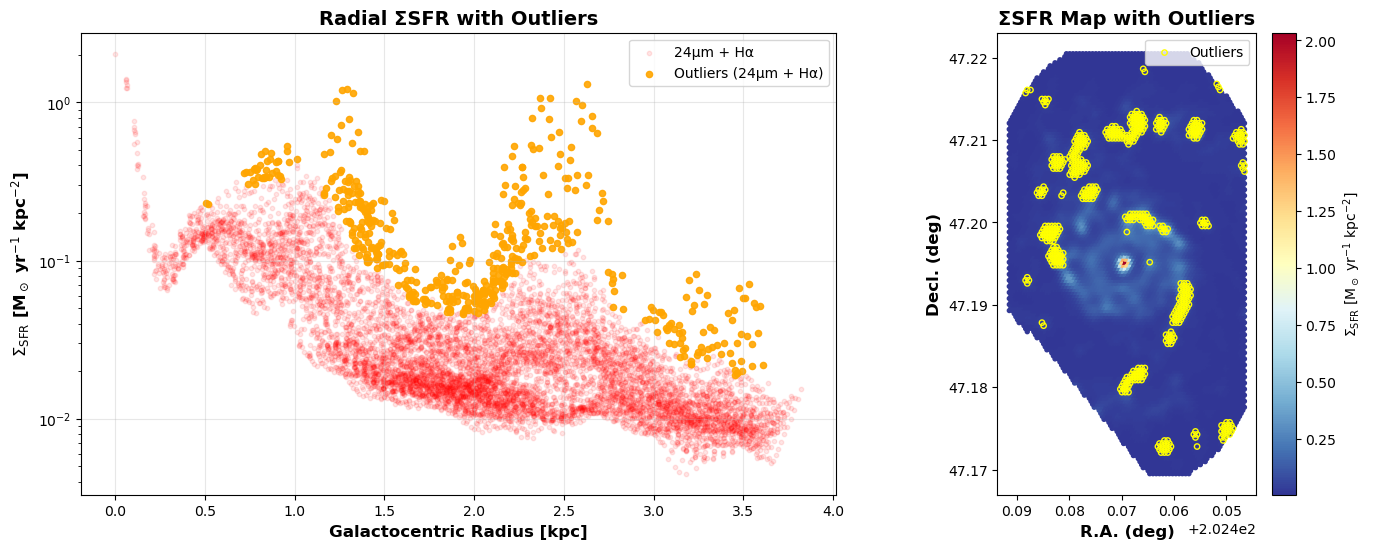

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# -------------------------------
# Basic arrays
# -------------------------------
rgal_kpc = struct["rgal_kpc"]
ra = struct["ra_deg"]
dec = struct["dec_deg"]
int_sfr = struct["INT_VAL_SIGMA_SFR24UM+HA"]

# --- Helper function: identify outliers along radial profile ---
def identify_outliers_radial(y, r, window_kpc=0.05, threshold=4.5):
    y = np.array(y)
    r = np.array(r)
    mask = ~np.isnan(y) & (y != 0)
    outliers = np.zeros_like(y, dtype=bool)
    
    for i in range(len(y)):
        if not mask[i]:
            continue
        neighbors = (r >= r[i] - window_kpc/2) & (r <= r[i] + window_kpc/2) & mask
        if np.sum(neighbors) < 3:
            continue
        local_values = y[neighbors]
        median = np.median(local_values)
        mad = np.median(np.abs(local_values - median))
        if mad == 0:
            continue
        modified_z = 0.6745 * (y[i] - median) / mad
        if np.abs(modified_z) > threshold:
            outliers[i] = True
    return outliers

# --- Identify ΣSFR outliers ---
outliers_uc_sfr = identify_outliers_radial(uc_sfr, rgal_kpc)

# =======================================================
# USER-SPECIFIED PANEL WIDTHS
# =======================================================
left_width = 0.7   # fraction of total width for left panel
right_width = 0.3  # fraction of total width for right panel
height = 6         # figure height in inches

fig = plt.figure(figsize=(16, height))
gs = gridspec.GridSpec(1, 2, width_ratios=[left_width, right_width], wspace=0.3)

# -------------------------
# Left panel: radial ΣSFR
# -------------------------
ax_left = fig.add_subplot(gs[0, 0])
ax_left.scatter(rgal_kpc[~outliers_uc_sfr], uc_sfr[~outliers_uc_sfr],
                c='red', s=10, alpha=0.1, label='24μm + Hα')
ax_left.scatter(rgal_kpc[outliers_uc_sfr], uc_sfr[outliers_uc_sfr],
                c='orange', s=20, alpha=0.9, label='Outliers (24μm + Hα)')
ax_left.set_yscale('log')
ax_left.set_xlabel("Galactocentric Radius [kpc]", fontsize=12, fontweight='bold')
ax_left.set_ylabel(r"$\Sigma_{\mathrm{SFR}}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]", fontsize=12, fontweight='bold')
ax_left.set_title("Radial ΣSFR with Outliers", fontsize=14, fontweight='bold')
ax_left.legend(fontsize=10)
ax_left.grid(alpha=0.3)

# -------------------------
# Right panel: galaxy map of ΣSFR
# -------------------------
ax_right = fig.add_subplot(gs[0, 1])
sc = ax_right.scatter(ra, dec, c=int_sfr, cmap='RdYlBu_r', s=8, alpha=1)
ax_right.scatter(ra[outliers_uc_sfr], dec[outliers_uc_sfr],
                 facecolors='none', edgecolors='yellow', s=15, linewidth=1.0,
                 marker='o', label='Outliers')
ax_right.invert_xaxis()
ax_right.set_xlabel("R.A. (deg)", fontsize=12, fontweight='bold')
ax_right.set_ylabel("Decl. (deg)", fontsize=12, fontweight='bold')
ax_right.set_title("ΣSFR Map with Outliers", fontsize=14, fontweight='bold')
ax_right.legend(loc='upper right', fontsize=10)

plt.colorbar(sc, ax=ax_right, label=r"$\Sigma_{\mathrm{SFR}}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")
plt.tight_layout()
plt.show()


## Implementation on all the tracers

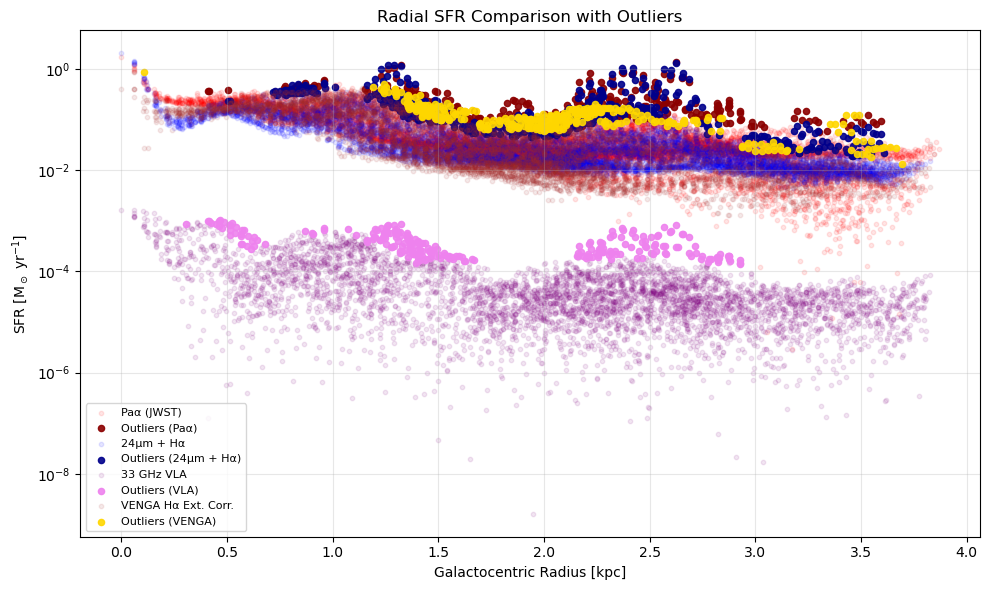

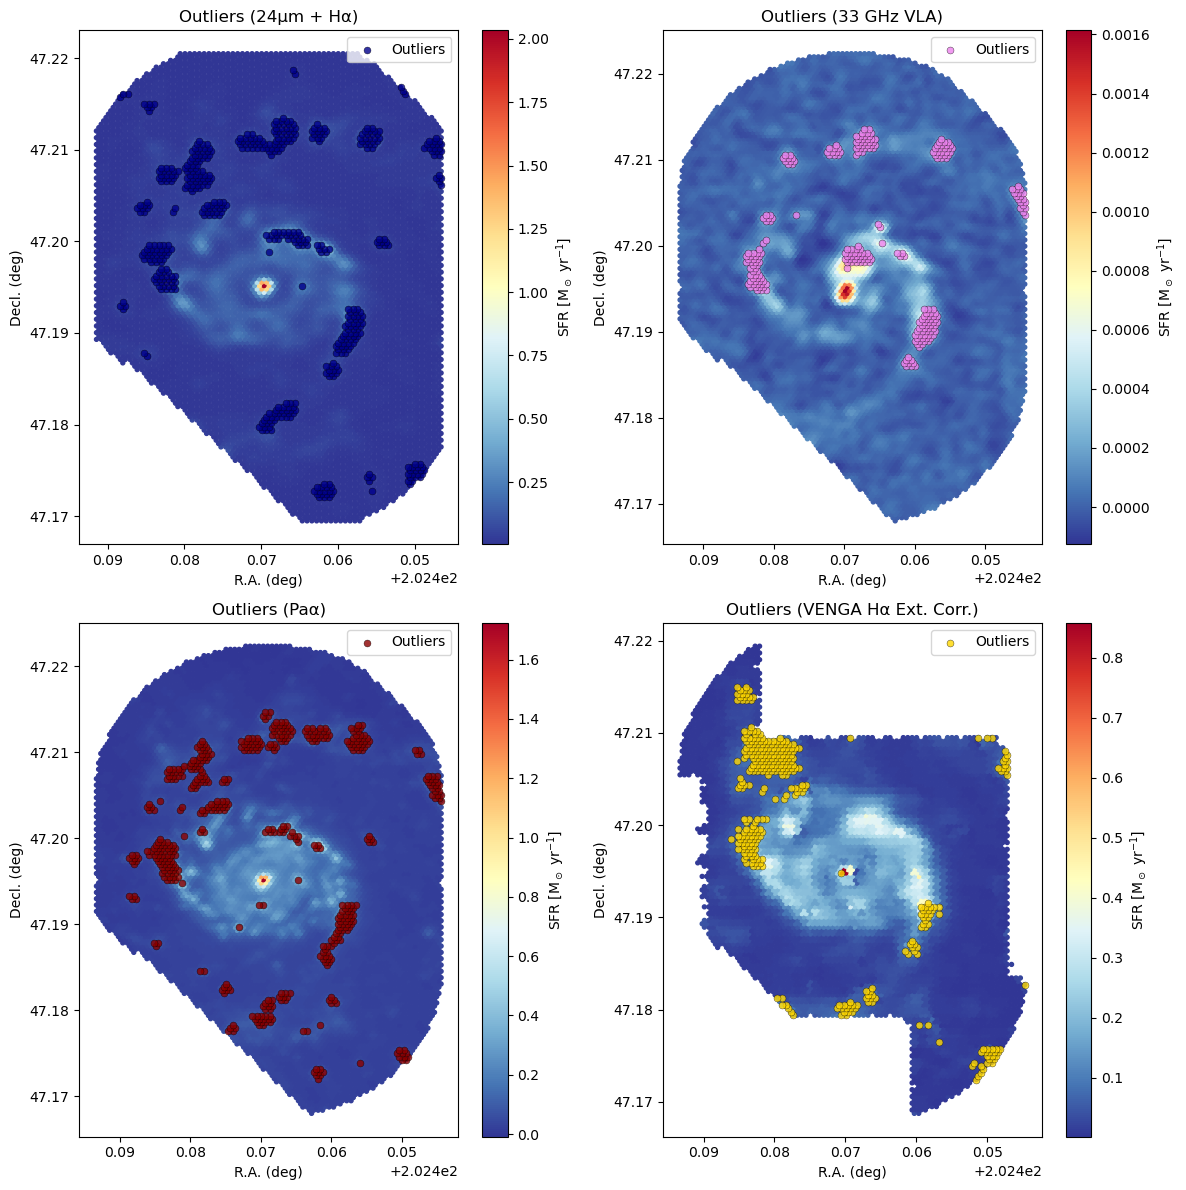

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Basic arrays
rgal_kpc = struct["rgal_kpc"]
ra = struct["ra_deg"]
dec = struct["dec_deg"]

# SFR arrays
sfr_pa_alpha = sig_SFR_kpc2  # Paα (JWST)
sfr_24um_ha = uc_sfr          # 24μm + Hα (Sophia corrected)
sfr_vla_arr = sfr_vla
sfr_venga_ext_corr = sigma_sfr_venga_extinction_corr

# --- Helper function: 1D radial profile MAD ---
def identify_outliers_radial(y, r, window_kpc=0.05, threshold=4.5):
    y = np.array(y)
    r = np.array(r)
    mask = ~np.isnan(y) & (y != 0)
    outliers = np.zeros_like(y, dtype=bool)
    
    for i in range(len(y)):
        if not mask[i]:
            continue
        neighbors = (r >= r[i] - window_kpc/2) & (r <= r[i] + window_kpc/2) & mask
        if np.sum(neighbors) < 3:
            continue
        local_values = y[neighbors]
        median = np.median(local_values)
        mad = np.median(np.abs(local_values - median))
        if mad == 0:
            continue
        modified_z = 0.6745 * (y[i] - median) / mad
        if np.abs(modified_z) > threshold:
            outliers[i] = True
    return outliers

# --- Identify outliers ---
outliers_pa = identify_outliers_radial(sfr_pa_alpha, rgal_kpc)
outliers_24um = identify_outliers_radial(sfr_24um_ha, rgal_kpc)
outliers_vla = identify_outliers_radial(sfr_vla_arr, rgal_kpc)
outliers_venga = identify_outliers_radial(sfr_venga_ext_corr, rgal_kpc)

# =======================================================
#  PLOT 1: Radial SFR comparison with outliers
# =======================================================
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Paα (JWST)
ax.scatter(rgal_kpc[~outliers_pa], sfr_pa_alpha[~outliers_pa], c='red', s=10, alpha=0.1, label='Paα (JWST)')
ax.scatter(rgal_kpc[outliers_pa], sfr_pa_alpha[outliers_pa], c='darkred', s=20, alpha=0.9, label='Outliers (Paα)')

# 24 μm + Hα (Sophia)
ax.scatter(rgal_kpc[~outliers_24um], sfr_24um_ha[~outliers_24um], c='blue', s=10, alpha=0.1, label='24μm + Hα')
ax.scatter(rgal_kpc[outliers_24um], sfr_24um_ha[outliers_24um], c='darkblue', s=20, alpha=0.9, label='Outliers (24μm + Hα)')

# 33 GHz VLA
ax.scatter(rgal_kpc[~outliers_vla], sfr_vla_arr[~outliers_vla], c='purple', s=10, alpha=0.1, label='33 GHz VLA')
ax.scatter(rgal_kpc[outliers_vla], sfr_vla_arr[outliers_vla], c='violet', s=20, alpha=0.9, label='Outliers (VLA)')

# VENGA Hα Ext. Corrected
ax.scatter(rgal_kpc[~outliers_venga], sfr_venga_ext_corr[~outliers_venga], c='brown', s=10, alpha=0.1, label='VENGA Hα Ext. Corr.')
ax.scatter(rgal_kpc[outliers_venga], sfr_venga_ext_corr[outliers_venga], c='gold', s=20, alpha=0.9, label='Outliers (VENGA)')

ax.set_yscale('log')
ax.set_xlabel("Galactocentric Radius [kpc]")
ax.set_ylabel(r"SFR [M$_\odot$ yr$^{-1}$]")
ax.set_title("Radial SFR Comparison with Outliers")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =======================================================
#  PLOT 2: Galaxy maps with 2x2 subplot grid showing outliers
# =======================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

sfr_arrays = [sfr_24um_ha, sfr_vla_arr, sfr_pa_alpha, sfr_venga_ext_corr]
outlier_masks = [outliers_24um, outliers_vla, outliers_pa, outliers_venga]
titles = ["Outliers (24μm + Hα)", "Outliers (33 GHz VLA)", "Outliers (Paα)", "Outliers (VENGA Hα Ext. Corr.)"]
colors = ["darkblue", "violet", "darkred", "gold"]

for i, ax in enumerate(axes.flatten()):
    mask = outlier_masks[i]
    color = colors[i]
    
    # Base map: color by SFR
    sc = ax.scatter(ra, dec, c=sfr_arrays[i], cmap='RdYlBu_r', s=8, alpha=1)
    
    # Highlight outliers
    ax.scatter(ra[mask], dec[mask], c=color, s=25, edgecolor='black', linewidth=0.3, alpha=0.8, label="Outliers")
    
    ax.invert_xaxis()
    ax.set_xlabel("R.A. (deg)")
    ax.set_ylabel("Decl. (deg)")
    ax.set_title(titles[i])
    ax.legend(loc='upper right')
    
    plt.colorbar(sc, ax=ax, label=r"SFR [M$_\odot$ yr$^{-1}$]")

plt.tight_layout()
plt.show()


## Contour plot of the high value of SFR and $\Sigma_{SFR}$

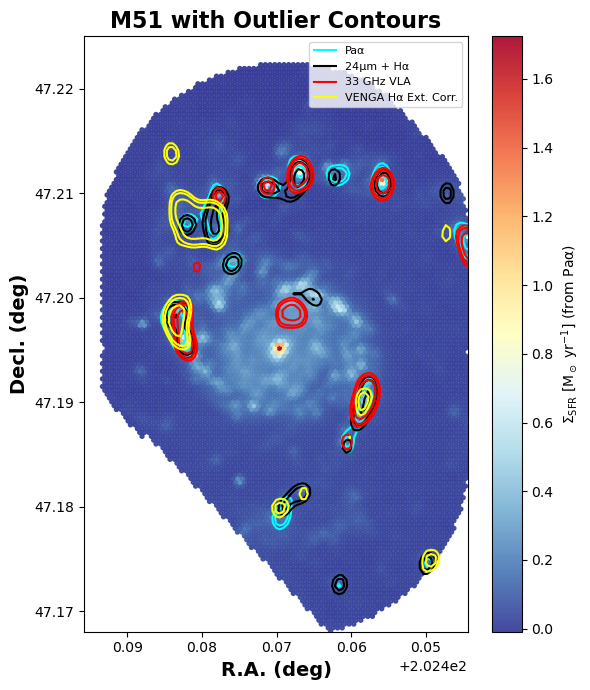

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

# -------------------------------
# Tracer information
# -------------------------------
sfr_tracers = [sfr_pa_alpha, sfr_24um_ha, sfr_vla_arr, sfr_venga_ext_corr]
outlier_masks = [outliers_pa, outliers_24um, outliers_vla, outliers_venga]
contour_colors = ['cyan', 'black', 'red', 'yellow']
tracer_labels = ['Paα', '24μm + Hα', '33 GHz VLA', 'VENGA Hα Ext. Corr.']

# -------------------------------
# Create figure
# -------------------------------
plt.figure(figsize=(6, 7))
ax = plt.gca()

# Base: plot all galaxy points using Paα SFR for color
sc = ax.scatter(ra, dec, c=sfr_pa_alpha, cmap='RdYlBu_r', s=8, alpha=0.9)
plt.colorbar(sc, ax=ax, label=r"$\Sigma_{\mathrm{SFR}}$ [M$_\odot$ yr$^{-1}$] (from Paα)")

# -------------------------------
# Overlay contours for each tracer
# -------------------------------
nbins = 100
xedges = np.linspace(ra.min(), ra.max(), nbins)
yedges = np.linspace(dec.min(), dec.max(), nbins)

for i in range(4):
    H, xedges_i, yedges_i = np.histogram2d(
        ra[outlier_masks[i]], dec[outlier_masks[i]], bins=[xedges, yedges]
    )
    H_smooth = gaussian_filter(H, sigma=1.5)
    
    mean_val = np.mean(H_smooth)
    std_val = np.std(H_smooth)
    levels = [mean_val + 1*std_val+ 2*std_val, mean_val + 4*std_val, mean_val + 6*std_val]

    X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
    ax.contour(X, Y, H_smooth.T, levels=levels, colors=contour_colors[i], linewidths=1.5)

# -------------------------------
# Add legend for contours
# -------------------------------
legend_elements = [Line2D([0], [0], color=contour_colors[i], lw=1.5, label=tracer_labels[i]) 
                   for i in range(4)]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# -------------------------------
# Final plot settings
# -------------------------------
ax.invert_xaxis()
ax.set_xlabel("R.A. (deg)", fontweight='bold', fontsize=14)
ax.set_ylabel("Decl. (deg)", fontweight='bold', fontsize=14)
ax.set_title("M51 with Outlier Contours", fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()
